# Bank churn: exploratory analysis

Two questions: which customers churn, and which columns are worth handing to a
model.

The order below runs from the base rate, to demographic splits, to behavioural
splits, to a correlation ranking that picks the final feature set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

df = pd.read_csv("bankchurners_clean.csv", index_col="CLIENTNUM")
print(df.shape)

(10127, 20)


## Base rate

16.1% of customers churned. Everything below is read against this number. A
segment is only interesting if it moves away from 16.1%, and a model is only
interesting if it beats predicting that nobody churns, which would be 83.9%
accurate and completely useless.

In [2]:
churn_rate = df['Churned'].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")
print(f"Retained: {(df['Churned'] == 0).sum()}")
print(f"Churned:  {(df['Churned'] == 1).sum()}")

Overall churn rate: 16.1%
Retained: 8500
Churned:  1627


## Demographics

Gender, income, education, marital status, and a gender by marital cross-tab.

None of these become model features. They are here because the fairness audit
needs per-group base rates to compare the model's behaviour against, and
because a demographic split that moves churn substantially is worth knowing
about even when it is deliberately not modelled.

In [3]:
gender_churn = df.groupby('Gender')['Churned'].mean() * 100
print(gender_churn.round(1))

Gender
F    17.4
M    14.6
Name: Churned, dtype: float64


In [4]:
income_churn = df.groupby('Income_Category', observed=False)['Churned'].mean() * 100
print(income_churn.round(1))

Income_Category
$120K +           17.3
$40K - $60K       15.1
$60K - $80K       13.5
$80K - $120K      15.8
Less than $40K    17.2
Name: Churned, dtype: float64


In [5]:
education_churn = df.groupby('Education_Level', observed=False)['Churned'].mean() * 100
print(education_churn.round(1))

Education_Level
College          15.2
Doctorate        21.1
Graduate         15.6
High School      15.2
Post-Graduate    17.8
Uneducated       15.9
Name: Churned, dtype: float64


In [6]:
marital_churn = df.groupby('Marital_Status', observed=False)['Churned'].mean() * 100
print(marital_churn.round(1))

Marital_Status
Divorced    16.2
Married     15.1
Single      16.9
Name: Churned, dtype: float64


In [7]:
cross_churn = df.groupby(['Marital_Status', 'Gender'], observed=False)['Churned'].mean() * 100
print(cross_churn.round(1))

Marital_Status  Gender
Divorced        F         16.9
                M         15.3
Married         F         16.8
                M         13.3
Single          F         17.9
                M         15.8
Name: Churned, dtype: float64


## Relationship and engagement counts

Moving from who the customer is to what the customer does: products held,
months inactive, and how often they contacted the bank.

Row counts are printed next to each rate because some of these groups are small
enough that the rate on its own is noisy.

In [8]:
# Group by relationship count, calculate mean churn rate per group
relationship_churn = df.groupby('Total_Relationship_Count')['Churned'].mean() * 100
print(relationship_churn.round(1))

Total_Relationship_Count
1    25.6
2    27.8
3    17.4
4    11.8
5    12.0
6    10.5
Name: Churned, dtype: float64


In [9]:
# Churn rate by months inactive
inactive_churn = df.groupby('Months_Inactive_12_mon')['Churned'].mean().mul(100).round(1)
print("Churn rate by months inactive (last 12 months):\n")
print(inactive_churn.to_string())
print(f"\nRow count per group:")
print(df['Months_Inactive_12_mon'].value_counts().sort_index())

Churn rate by months inactive (last 12 months):

Months_Inactive_12_mon
0    51.7
1     4.5
2    15.4
3    21.5
4    29.9
5    18.0
6    15.3

Row count per group:
Months_Inactive_12_mon
0      29
1    2233
2    3282
3    3846
4     435
5     178
6     124
Name: count, dtype: int64


In [10]:
# Churn rate by number of times customer contacted the bank (last 12 months)
contacts_churn = df.groupby('Contacts_Count_12_mon')['Churned'].mean().mul(100).round(1)
print("Churn rate by contacts count (last 12 months):\n")
print(contacts_churn.to_string())
print(f"\nRow count per group:")
print(df['Contacts_Count_12_mon'].value_counts().sort_index())

Churn rate by contacts count (last 12 months):

Contacts_Count_12_mon
0      1.8
1      7.2
2     12.5
3     20.1
4     22.6
5     33.5
6    100.0

Row count per group:
Contacts_Count_12_mon
0     399
1    1499
2    3227
3    3380
4    1392
5     176
6      54
Name: count, dtype: int64


## Behaviour, binned into deciles

Transaction count, transaction amount, and utilisation are continuous, so a raw
group-by would produce one group per distinct value and no readable trend.

Cutting into deciles gives ten groups with roughly equal support, which makes
the trend legible and stops a single customer from appearing to be a segment.

In [11]:
# Churn rate by total number of transactions in last 12 months (binned into deciles)
df['Trans_Ct_Bin'] = pd.qcut(df['Total_Trans_Ct'], q=10)
trans_ct_churn = df.groupby('Trans_Ct_Bin', observed=True)['Churned'].mean().mul(100).round(1)
print("Churn rate by transaction count decile:\n")
print(trans_ct_churn.to_string())
df.drop(columns=['Trans_Ct_Bin'], inplace=True)

Churn rate by transaction count decile:

Trans_Ct_Bin
(9.999, 33.0]    26.6
(33.0, 41.0]     38.5
(41.0, 50.0]     48.4
(50.0, 61.0]     20.9
(61.0, 67.0]      8.1
(67.0, 73.0]      5.4
(73.0, 78.0]      4.5
(78.0, 83.0]      2.1
(83.0, 92.0]      2.0
(92.0, 139.0]     0.1


In [12]:
# Churn rate by total transaction dollar amount in last 12 months (binned into deciles)
df['Trans_Amt_Bin'] = pd.qcut(df['Total_Trans_Amt'], q=10, duplicates='drop')
trans_amt_churn = df.groupby('Trans_Amt_Bin', observed=True)['Churned'].mean().mul(100).round(1)
print("Churn rate by transaction amount decile:\n")
print(trans_amt_churn.to_string())
df.drop(columns=['Trans_Amt_Bin'], inplace=True)

Churn rate by transaction amount decile:

Trans_Amt_Bin
(509.999, 1501.0]    21.9
(1501.0, 1914.0]     18.9
(1914.0, 2411.0]     47.0
(2411.0, 3192.4]     40.8
(3192.4, 3899.0]      1.3
(3899.0, 4267.0]      0.4
(4267.0, 4572.0]      0.5
(4572.0, 4926.0]      3.9
(4926.0, 8212.4]     13.4
(8212.4, 18484.0]    12.6


In [13]:
# Churn rate by average credit utilization ratio (binned into deciles)
df['Util_Bin'] = pd.qcut(df['Avg_Utilization_Ratio'], q=10, duplicates='drop')
util_churn = df.groupby('Util_Bin', observed=True)['Churned'].mean().mul(100).round(1)
print("Churn rate by utilization ratio decile:\n")
print(util_churn.to_string())
df.drop(columns=['Util_Bin'], inplace=True)

Churn rate by utilization ratio decile:

Util_Bin
(-0.001, 0.051]    32.4
(0.051, 0.1]        8.2
(0.1, 0.176]        9.4
(0.176, 0.277]      9.4
(0.277, 0.43]      10.5
(0.43, 0.573]       6.5
(0.573, 0.707]      6.0
(0.707, 0.999]     13.2


## Ranking features by correlation with churn

This is the ranking that selects the model's feature set.

It is univariate, so it misses interactions and non-linear effects. That is a
real limitation of the approach rather than an oversight, and it is stated as
one in the README.

In [14]:
# Correlation matrix for all numeric columns vs Churned
numeric_cols = df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()
print(corr_matrix['Churned'].sort_values())

Total_Trans_Ct             -0.371403
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Revolving_Bal        -0.263053
Avg_Utilization_Ratio      -0.178410
Total_Trans_Amt            -0.168598
Total_Relationship_Count   -0.150005
Total_Amt_Chng_Q4_Q1       -0.131063
Credit_Limit               -0.023873
Avg_Open_To_Buy            -0.000285
Months_on_book              0.013687
Customer_Age                0.018203
Dependent_count             0.018991
Months_Inactive_12_mon      0.152449
Contacts_Count_12_mon       0.204491
Churned                     1.000000
Name: Churned, dtype: float64


## Checking the top 5 before committing to them

Correlation alone can be driven by outliers or by an odd distribution shape.
Overlaying the churned and retained distributions for each of the five
candidates confirms the separation is real and roughly monotonic before they go
into the model.

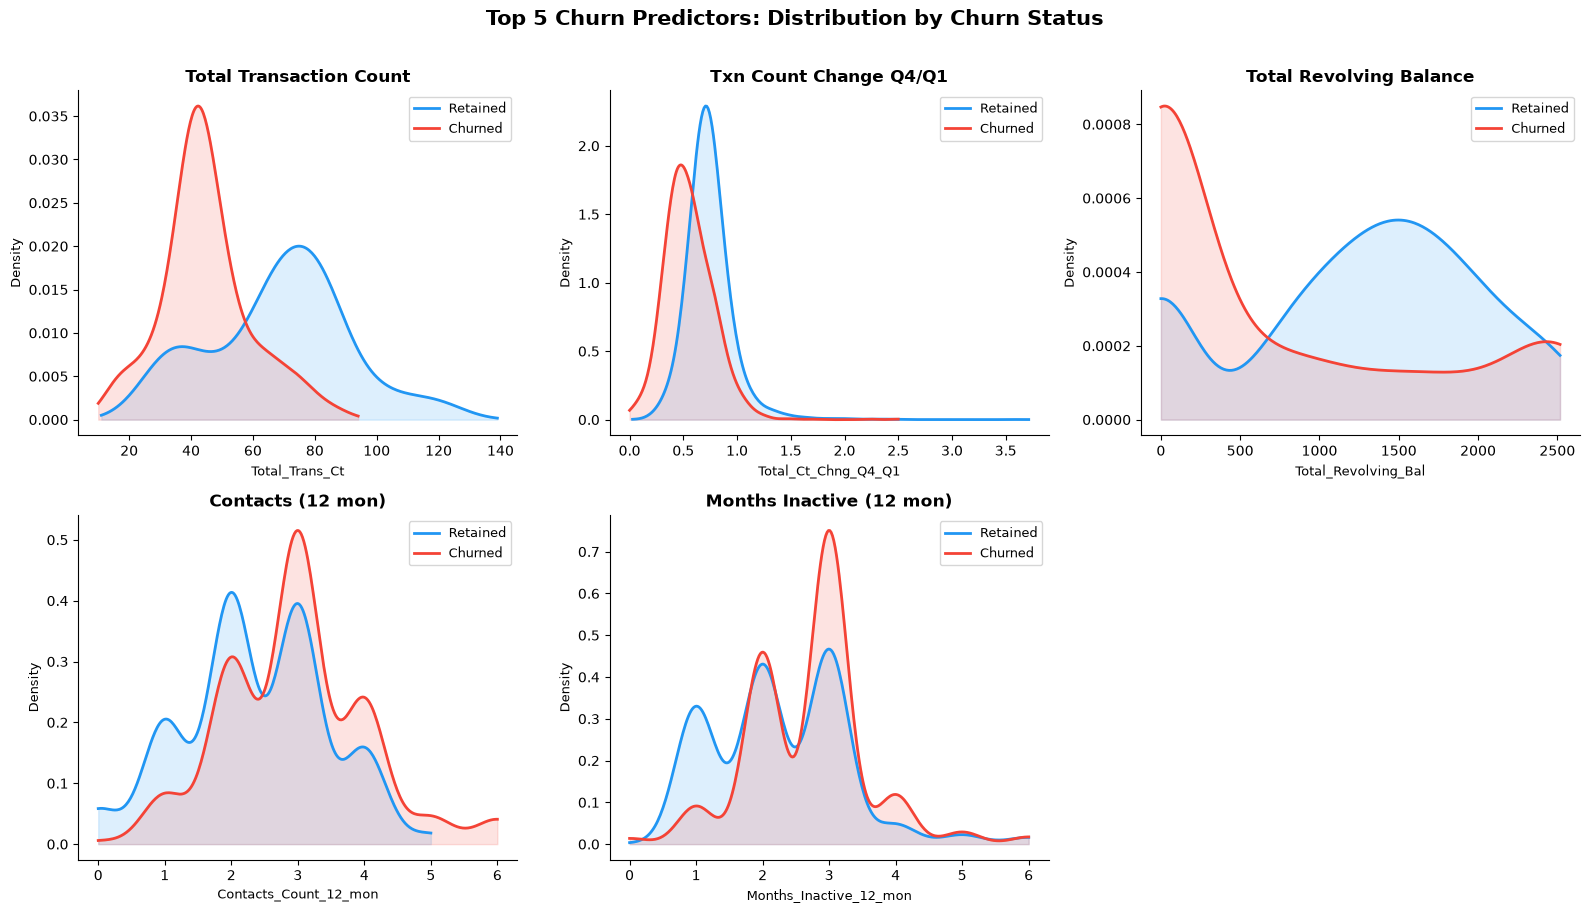

In [15]:
# Step 13: Distribution comparison — top 5 features, churned vs retained

top5 = [
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Revolving_Bal',
    'Contacts_Count_12_mon',
    'Months_Inactive_12_mon'
]

labels = {
    'Total_Trans_Ct': 'Total Transaction Count',
    'Total_Ct_Chng_Q4_Q1': 'Txn Count Change Q4/Q1',
    'Total_Revolving_Bal': 'Total Revolving Balance',
    'Contacts_Count_12_mon': 'Contacts (12 mon)',
    'Months_Inactive_12_mon': 'Months Inactive (12 mon)'
}

retained = df[df['Churned'] == 0]
churned  = df[df['Churned'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top5):
    ax = axes[i]
    for subset, color, label in [
        (retained, '#2196F3', 'Retained'),
        (churned,  '#F44336', 'Churned')
    ]:
        data = subset[col].dropna()
        # KDE
        kde = gaussian_kde(data, bw_method=0.3)
        x   = np.linspace(data.min(), data.max(), 300)
        ax.plot(x, kde(x), color=color, linewidth=2, label=label)
        ax.fill_between(x, kde(x), alpha=0.15, color=color)

    ax.set_title(labels[col], fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# hide unused 6th panel
axes[5].set_visible(False)
fig.suptitle('Top 5 Churn Predictors: Distribution by Churn Status',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_top5_distributions.png', dpi=150, bbox_inches='tight')
plt.show()